# Penguins - Application of Data Visualisation

In [1]:
# Standard imports for EDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv("Code files/penguins_size.csv")

# Preview the first few rows
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [3]:
# Dataset shape and data types
print("Shape:", df.shape)
print()
print(df.info())

Shape: (344, 7)

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB
None


In [4]:
# Count missing values per column
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64


## Data cleaning

In [5]:
# Drop rows where physical measurements are missing
df_clean = df.dropna(subset=[
    "culmen_length_mm",
    "culmen_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
])

# Confirm the result
print("Rows before cleaning:", len(df))
print("Rows after cleaning:", len(df_clean))
print("Missing values remaining:")
print(df_clean.isnull().sum())

Rows before cleaning: 344
Rows after cleaning: 342
Missing values remaining:
species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  8
dtype: int64


## Preprocessing

In [6]:
# Summary statistics for numerical columns
df_clean.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [7]:
# Count of each species and island
print("Species counts:")
print(df_clean["species"].value_counts())
print()
print("Island counts:")
print(df_clean["island"].value_counts())

Species counts:
species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64

Island counts:
island
Biscoe       167
Dream        124
Torgersen     51
Name: count, dtype: int64


## Exploratory Data Analysis

### 1) Penguin count by Species

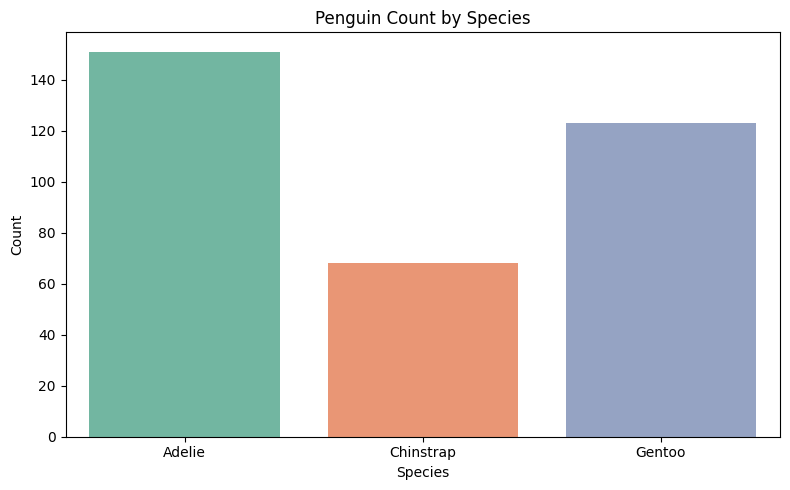

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_clean,
    x="species",
    hue="species",
    palette="Set2",
    legend=False
)
plt.title("Penguin Count by Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("chart1_species_count.png", dpi=150)
plt.show()

### 2) Species distribution across Islands

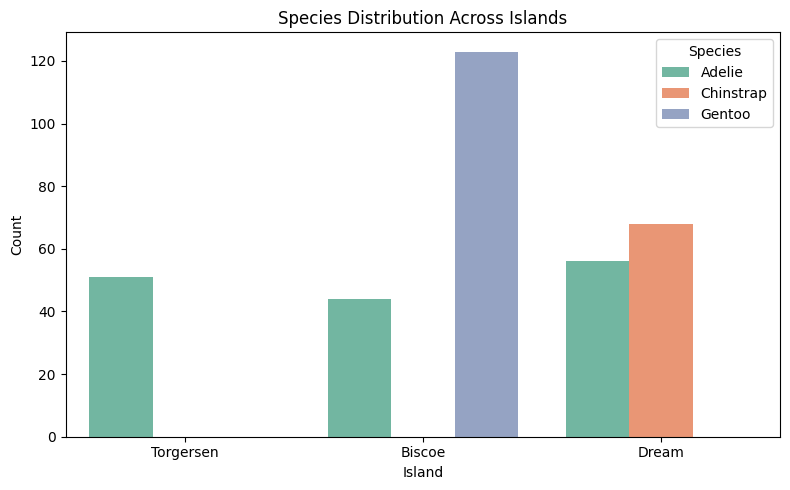

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_clean,
    x="island",
    hue="species",
    palette="Set2"
)
plt.title("Species Distribution Across Islands")
plt.xlabel("Island")
plt.ylabel("Count")
plt.legend(title="Species")
plt.tight_layout()
plt.savefig("chart2_species_island.png", dpi=150)
plt.show()

### 3) Body mass distribution by Species

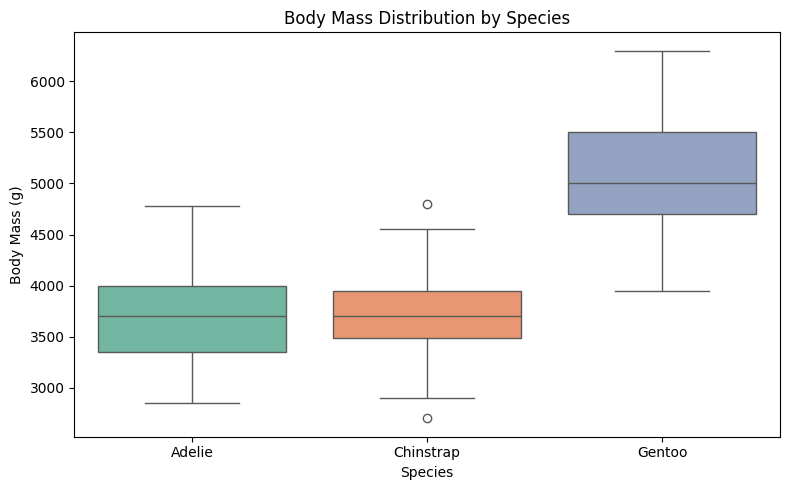

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_clean,
    x="species",
    y="body_mass_g",
    hue="species",
    palette="Set2",
    legend=False
)
plt.title("Body Mass Distribution by Species")
plt.xlabel("Species")
plt.ylabel("Body Mass (g)")
plt.tight_layout()
plt.savefig("chart3_body_mass.png", dpi=150)
plt.show()